(markov_perf)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 马尔可夫完美均衡

```{index} single: 马尔可夫完美均衡
```

```{contents} 目录
:depth: 2
```

除了Anaconda中已有的库外，本讲座还需要以下库：

In [1]:
!pip install quantecon

## 概述

```{index} single: 马尔可夫完美均衡; 概述
```

本讲座介绍马尔可夫完美均衡的概念。

马尔可夫完美均衡是分析涉及动态战略互动的经济问题的关键概念，也是应用博弈论的基石。

在本讲座中，我们将通过示例来讲解马尔可夫完美均衡。

我们将重点关注具有以下特征的设定：

* 两个参与者
* 二次效用函数
* 状态的线性转移规则

其他参考文献包括{cite}`Ljungqvist2012`的第7章。

让我们从一些标准导入开始：

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']

plt.rcParams["figure.figsize"] = (11, 5)  #设置默认图形大小
import numpy as np
import quantecon as qe

## 背景

```{index} single: 马尔可夫完美均衡; 背景
```

马尔可夫完美均衡是纳什均衡概念的一种细化。

它用于研究多个决策者在时间维度上非合作互动的情况，每个决策者都在追求自己的目标。

模型中的参与者面对一个共同的状态向量，其时间路径既受到参与者决策的影响，也会影响他们的决策。

具体而言，每个参与者所面对的状态转移规律都会受到其他参与者决策规则的影响。

为了实现个体收益最大化，每个参与者都需要解决一个包含这种转移规律的动态规划问题。

当所有参与者在给定其他参与者策略的情况下都不想修改自己的策略时，就达到了马尔可夫完美均衡。

著名的例子包括：

* 行业内企业对价格、产出、位置或产能的选择（例如，{cite}`ericson1995markov`、{cite}`ryan2012costs`、{cite}`doraszelski2010computable`）。

* 从共享自然资源中的开采率，例如渔业（如{cite}`levhari1980great`，{cite}`van2011dynamic`）。

让我们来研究第一类模型。

### 示例：双寡头模型

两家公司是某种商品的唯一生产者，该商品的需求由线性反向需求函数决定

```{math}
:label: game2

p = a_0 - a_1 (q_1 +  q_2)
```

这里$p = p_t$是商品价格，$q_i = q_{it}$是第$i=1,2$家公司在$t$时刻的产量，且$a_0 > 0, a_1 >0$。

在{eq}`game2`和后文中，

* 为简化符号，在可能的情况下省略时间下标
* $\hat x$表示变量$x$的下一期值

每家公司都意识到其产量会影响总产量，从而影响市场价格。

公司$i$的单期收益函数是价格乘以数量减去调整成本：

```{math}
:label: game1

\pi_i = p q_i - \gamma (\hat q_i - q_i)^2, \quad \gamma > 0 ,
```

将逆需求曲线{eq}`game2`代入{eq}`game1`，我们可以将单期收益表示为

```{math}
:label: game3

\pi_i(q_i, q_{-i}, \hat q_i) = a_0 q_i - a_1 q_i^2 - a_1 q_i q_{-i} - \gamma (\hat q_i - q_i)^2 ,
```

其中$q_{-i}$表示除$i$之外的企业的产量。

企业的目标是最大化$\sum_{t=0}^\infty \beta^t \pi_{it}$。

企业$i$选择一个决策规则，将下一期的产量$\hat q_i$设定为当前状态$(q_i, q_{-i})$的函数$f_i$。

马尔可夫完美均衡的一个重要特征是每个企业都将其他企业的决策规则视为已知和既定的。

给定$f_{-i}$，企业$i$的贝尔曼方程为

```{math}
:label: game4

v_i(q_i, q_{-i}) = \max_{\hat q_i}
   \left\{\pi_i (q_i, q_{-i}, \hat q_i) + \beta v_i(\hat q_i, f_{-i}(q_{-i}, q_i)) \right\}
```

```{prf:definition} 马尔可夫完美均衡
:label: def-markov-perfect-equilibrium

双头垄断模型的**马尔可夫完美均衡**是一对价值函数$(v_1, v_2)$和一对策略函数$(f_1, f_2)$，对于每个$i \in \{1, 2\}$和每个可能的状态，满足：

* 价值函数$v_i$满足贝尔曼方程{eq}`game4`。
* {eq}`game4`右侧的最大化值等于$f_i(q_i, q_{-i})$。

形容词"马尔可夫"表示均衡决策规则仅依赖于状态变量的当前值，而不依赖于它们历史的其他部分。

"完美"意味着完整，即均衡是通过反向归纳构建的，因此在所有可能的未来状态下都包含了每个公司的优化行为。

* 这包括了许多状态，当我们从给定的初始状态开始，在一对均衡策略$f_i$上向前迭代时，这些状态不会被达到。
```

### 计算

计算马尔可夫完美均衡的一种策略是对贝尔曼方程和决策规则的配对进行迭代收敛。

具体来说，令$v_i^j,f_i^j$分别为第$j$次迭代时企业$i$的价值函数和策略函数。

设想构造迭代式

```{math}
:label: game6

v_i^{j+1}(q_i, q_{-i}) = \max_{\hat q_i}
   \left\{\pi_i (q_i, q_{-i}, \hat q_i) + \beta v^j_i(\hat q_i, f_{-i}(q_{-i}, q_i)) \right\}
```

在计算实现上，这些迭代可能具有挑战性。

然而，当单期收益函数为二次型且转移规律为线性时，这些迭代会变得简单——这就引出了我们的下一个话题。

## 线性马尔可夫完美均衡

```{index} single: Linear Markov Perfect Equilibria
```

正如我们在双寡头例子中看到的，研究两个参与者博弈中的马尔可夫完美均衡会导向一对相互关联的贝尔曼方程。

在线性二次动态博弈中，这些"叠加贝尔曼方程"变成了具有可处理数学结构的"叠加黎卡提方程"。

我们将在一般设置中阐述这个结构，然后将其应用于一些简单问题。

### 耦合线性调节器问题

我们考虑一个具有两个参与者的一般线性二次调节器博弈。

为方便起见，我们从有限时域表述开始，其中$t_0$是初始日期，$t_1$是共同的终止日期。

参与者$i$将$\{u_{-it}\}$视为给定，并最小化

```{math}
:label: orig-1

\sum_{t=t_0}^{t_1 - 1}
\beta^{t - t_0}
\left\{
    x_t' R_i x_t +
    u_{it}' Q_i u_{it} +
    u_{-it}' S_i u_{-it} +
    2 x_t' W_i u_{it} +
    2 u_{-it}' M_i u_{it}
\right\}
```

同时状态按照以下方式演变：

```{math}
:label: orig-0

x_{t+1} = A x_t + B_1 u_{1t} + B_2 u_{2t}
```

这里

* $x_t$是一个$n \times 1$状态向量，$u_{it}$是参与者$i$的一个$k_i \times 1$控制向量
* $R_i$是$n \times n$维的

* $S_i$ 是 $k_{-i} \times k_{-i}$ 矩阵
* $Q_i$ 是 $k_i \times k_i$ 矩阵
* $W_i$ 是 $n \times k_i$ 矩阵
* $M_i$ 是 $k_{-i} \times k_i$ 矩阵
* $A$ 是 $n \times n$ 矩阵
* $B_i$ 是 $n \times k_i$ 矩阵

### 计算均衡

我们将线性马尔可夫完美均衡表述如下。

玩家 $i$ 采用线性决策规则 $u_{it} = - F_{it} x_t$，其中 $F_{it}$ 是一个 $k_i \times n$ 矩阵。

马尔可夫完美均衡是一对序列 $\{F_{1t}, F_{2t}\}$，在 $t = t_0, \ldots, t_1 - 1$ 上满足

* $\{F_{1t}\}$ 在给定 $\{F_{2t}\}$ 的情况下解决玩家1的问题，且
* $\{F_{2t}\}$ 在给定 $\{F_{1t}\}$ 的情况下解决玩家2的问题

如果我们取 $u_{2t} = - F_{2t} x_t$ 并将其代入 {eq}`orig-1` 和 {eq}`orig-0`，那么玩家1的问题变成最小化

```{math}
:label: eq_mpe_p1p

\sum_{t=t_0}^{t_1 - 1}
\beta^{t - t_0}
    \left\{
    x_t' \Pi_{1t} x_t +
    u_{1t}' Q_1 u_{1t} +
    2 u_{1t}' \Gamma_{1t} x_t
    \right\}
```

约束条件为

```{math}
:label: eq_mpe_p1d

x_{t+1} = \Lambda_{1t} x_t + B_1 u_{1t},
```

其中

* $\Lambda_{it} := A - B_{-i} F_{-it}$
* $\Pi_{it} := R_i + F_{-it}' S_i F_{-it}$
* $\Gamma_{it} := W_i' - M_i' F_{-it}$

这是一个可以通过反向求解的LQ动态规划问题。

解决此问题的决策规则是

```{math}
:label: orig-3

F_{1t}
= (Q_1 + \beta B_1' P_{1t+1} B_1)^{-1}
(\beta B_1' P_{1t+1} \Lambda_{1t} + \Gamma_{1t})
```

其中$P_{1t}$满足矩阵Riccati差分方程

```{math}
:label: orig-4

P_{1t} =
\Pi_{1t} - (\beta B_1' P_{1t+1} \Lambda_{1t} +
\Gamma_{1t})' (Q_1 + \beta B_1' P_{1t+1} B_1)^{-1}
(\beta B_1' P_{1t+1} \Lambda_{1t} + \Gamma_{1t}) +
\beta \Lambda_{1t}' P_{1t+1} \Lambda_{1t}
```

类似地，解决玩家2问题的决策规则是

```{math}
:label: orig-5

F_{2t} = (Q_2 + \beta B_2' P_{2t+1} B_2)^{-1}
(\beta B_2' P_{2t+1} \Lambda_{2t} + \Gamma_{2t})
```

其中$P_{2t}$满足

```{math}
:label: orig-6

P_{2t} =

\Pi_{2t} - (\beta B_2' P_{2t+1} \Lambda_{2t} +
\Gamma_{2t})' (Q_2 + \beta B_2' P_{2t+1} B_2)^{-1}
(\beta B_2' P_{2t+1} \Lambda_{2t} + \Gamma_{2t}) +
\beta \Lambda_{2t}' P_{2t+1} \Lambda_{2t}
```

在所有情况下，$t = t_0, \ldots, t_1 - 1$，且终端条件为$P_{it_1} = 0$。

求解过程是使用方程{eq}`orig-3`、{eq}`orig-4`、{eq}`orig-5`和{eq}`orig-6`，从时间$t_1 - 1$开始"向后推算"。

由于我们是向后推算，在每个阶段$P_{1t+1}$和$P_{2t+1}$都被视为已知。

此外，由于

* {eq}`orig-3`右侧的某些项包含$F_{2t}$
* {eq}`orig-5`右侧的某些项包含$F_{1t}$

我们需要同时求解这$k_1 + k_2$个方程。

#### 关键洞察

一个关键洞察是方程{eq}`orig-3`和{eq}`orig-5`对$F_{1t}$和$F_{2t}$是线性的。

在求解这些方程之后，我们可以利用$F_{it}$来求解{eq}`orig-4`和{eq}`orig-6`中的$P_{it}$。

#### 无限视界

我们通常希望计算这类博弈在无限视界下的解，期望决策规则 $F_{it}$ 在 $t_1 \rightarrow +\infty$ 时趋于时间不变。

在实践中，我们通常固定 $t_1$ 并通过让 $t_0 \rightarrow - \infty$ 来计算无限视界博弈的均衡。

这就是我们在下一节采用的方法。

### 实现

我们使用 [QuantEcon.py](https://quantecon.org/quantecon-py/) 中的 [nnash](https://github.com/QuantEcon/QuantEcon.py/blob/master/quantecon/lqnash.py) 函数，该函数按照上述方式计算无限视界线性二次动态博弈的马尔可夫完美均衡。

## 应用

```{index} single: Markov Perfect Equilibrium; Applications
```

让我们用这些程序来处理一些应用，首先从双寡头模型开始。

### 双寡头模型

为了将双寡头模型映射到耦合的线性二次动态规划问题中，定义状态和控制变量为

$$
x_t :=
\begin{bmatrix}
    1 \\
    q_{1t} \\
    q_{2t}
\end{bmatrix}
\quad \text{and} \quad
u_{it} :=
q_{i,t+1} - q_{it}, \quad i=1,2
$$

如果我们写作

$$
x_t' R_i x_t + u_{it}' Q_i u_{it}
$$

其中 $Q_1 = Q_2 = \gamma$，

$$
R_1 :=
\begin{bmatrix}
   0              & -\frac{a_0}{2}  & 0 \\
   -\frac{a_0}{2} &  a_1            &  \frac{a_1}{2} \\
   0              &   \frac{a_1}{2} & 0
\end{bmatrix}
\quad \text{and} \quad
R_2 :=
\begin{bmatrix}
   0              & 0             & -\frac{a_0}{2} \\
   0              & 0             & \frac{a_1}{2} \\
   -\frac{a_0}{2} & \frac{a_1}{2} & a_1
\end{bmatrix}
$$

那么我们就得到了表达式{eq}`game3`中的单期收益。

状态 $x_t$ 的运动方程为 $x_{t+1} = A x_t + B_1 u_{1t} + B_2 u_{2t}$，其中

$$
A :=
\begin{bmatrix}
   1 & 0 & 0 \\
   0 & 1 & 0 \\
   0 & 0 & 1
\end{bmatrix},
\quad
B_1 :=
\begin{bmatrix}
       0 \\
       1 \\
       0
\end{bmatrix},
\quad
B_2 :=
\begin{bmatrix}
            0 \\
            0 \\
            1
\end{bmatrix}
$$

企业$i$的最优决策规则将采用$u_{it} = - F_i x_t$的形式，在马尔可夫完美均衡中导致$x$演变的闭环系统如下：

```{math}
:label: eq_mpe_cle

x_{t+1} = (A - B_1 F_1 -B_1 F_2 ) x_t
```

### 参数和解决方案

考虑之前提出的双寡头模型，参数值为：

* $a_0 = 10$
* $a_1 = 2$
* $\beta = 0.96$
* $\gamma = 12$

根据这些参数，我们使用前面的代码计算无限期MPE

In [3]:
import numpy as np
import quantecon as qe

# Parameters
a0 = 10.0
a1 = 2.0
β = 0.96
γ = 12.0

# In LQ form
A = np.eye(3)
B1 = np.array([[0.], [1.], [0.]])
B2 = np.array([[0.], [0.], [1.]])


R1 = [[      0.,     -a0 / 2,          0.],
      [-a0 / 2.,          a1,     a1 / 2.],
      [       0,     a1 / 2.,          0.]]

R2 = [[     0.,           0.,      -a0 / 2],
      [     0.,           0.,      a1 / 2.],
      [-a0 / 2,      a1 / 2.,           a1]]

Q1 = Q2 = γ
S1 = S2 = W1 = W2 = M1 = M2 = 0.0

# Solve using QE's nnash function
F1, F2, P1, P2 = qe.nnash(A, B1, B2, R1, R2, Q1, 
                          Q2, S1, S2, W1, W2, M1, 
                          M2, beta=β)

# Display policies
print("Computed policies for firm 1 and firm 2:\n")
print(f"F1 = {F1}")
print(f"F2 = {F2}")
print("\n")


Computed policies for firm 1 and firm 2:

F1 = [[-0.66846615  0.29512482  0.07584666]]
F2 = [[-0.66846615  0.07584666  0.29512482]]


运行代码会产生以下输出。

通过使用[QuantEcon.py](https://quantecon.org/quantecon-py/)的LQ类，我们可以看到$F_i$确实是在给定$F_2$的情况下对公司$i$来说是最优的。

具体来说，让我们把上面计算得到的F2代入{eq}`eq_mpe_p1p`和{eq}`eq_mpe_p1d`中得到公司1的问题，并使用LQ来求解。

我们希望得到的策略与上面计算的F1一致。

In [4]:
beta = 0.96
Λ1 = A - B2 @ F2
lq1 = qe.LQ(Q1, R1, Λ1, B1, beta=beta)
P1_ih, F1_ih, d = lq1.stationary_values()
F1_ih

array([[-0.66846613,  0.29512482,  0.07584666]])

正如业内人士所说，这已经足够接近了。

事实上，np.allclose也认同我们的判断

In [5]:
np.allclose(F1, F1_ih)

True

### 动态分析

让我们现在研究在这个简单双寡头模型中，在MPE策略下价格和产出的动态变化。

基于我们的最优策略$F1$和$F2$，状态按照{eq}`eq_mpe_cle`方程演变。

以下程序将：

* 从之前的程序中导入$F1$和$F2$以及所有参数。
* 使用{eq}`eq_mpe_cle`计算$x_t$的演变。
* 提取并绘制行业总产出$q_t = q_{1t} + q_{2t}$和价格$p_t = a_0 - a_1 q_t$。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


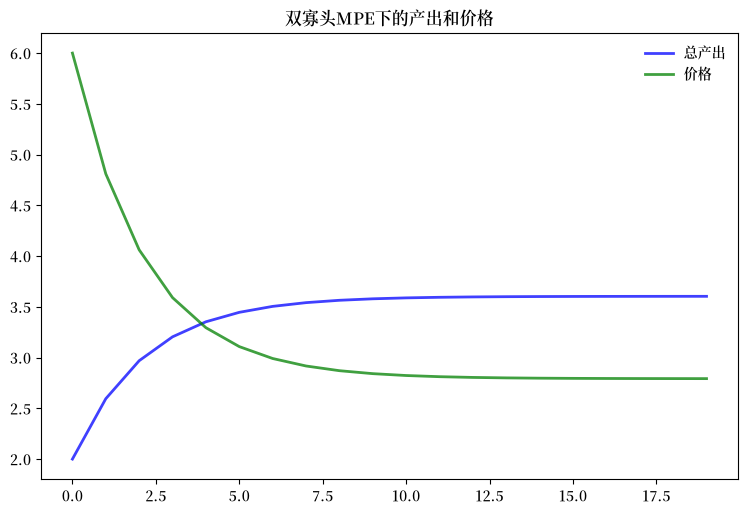

In [6]:
AF = A - B1 @ F1 - B2 @ F2
n = 20
x = np.empty((3, n))
x[:, 0] = 1, 1, 1
for t in range(n-1):
    x[:, t+1] = AF @ x[:, t]
q1 = x[1, :]
q2 = x[2, :]
q = q1 + q2       # 总产出，MPE
p = a0 - a1 * q   # 价格，MPE

fig, ax = plt.subplots(figsize=(9, 5.8))
ax.plot(q, 'b-', lw=2, alpha=0.75, label='总产出')
ax.plot(p, 'g-', lw=2, alpha=0.75, label='价格')
ax.set_title('双寡头MPE下的产出和价格')
ax.legend(frameon=False)
plt.show()

注意初始条件设定为 $q_{10} = q_{20} = 1.0$。

为了获得一些视角，我们可以将其与垄断情况下的结果进行比较。

下图的第一个面板比较了垄断者的产出和MPE下的行业产出随时间的变化。

第二个面板显示了价格的类似曲线。

(mpe_vs_monopolist)=
```{figure} /_static/lecture_specific/markov_perf/mpe_vs_monopolist.png

```

这里MPE和垄断解的参数设置都与上面相同。

垄断者的初始条件是 $q_0 = 2.0$，以模拟MPE情况下的行业初始条件 $q_{10} = q_{20} = 1.0$。

正如预期的那样，在双寡头情况下，产出更高，价格更低。

## 练习

```{exercise}
:label: mp_ex1

复现{ref}`这对图表<mpe_vs_monopolist>`，展示垄断者和MPE下双寡头的产出和价格比较。

参数与 duopoly_mpe.py 中的相同,你可以使用该代码计算双寡头垄断下的 MPE 策略。

垄断者情况下的最优策略可以使用 [QuantEcon.py](https://quantecon.org/quantecon-py/) 的 LQ 类来计算。
```

```{solution-start} mp_ex1
:class: dropdown
```

首先,让我们用给定参数计算双寡头垄断的 MPE

In [7]:
# == 参数 == #
a0 = 10.0
a1 = 2.0
β = 0.96
γ = 12.0

# == LQ 形式 == #
A  = np.eye(3)
B1 = np.array([[0.], [1.], [0.]])
B2 = np.array([[0.], [0.], [1.]])
R1 = [[      0.,      -a0/2,          0.],
      [-a0 / 2.,         a1,     a1 / 2.],
      [       0,    a1 / 2.,          0.]]

R2 = [[     0.,          0.,     -a0 / 2],
      [     0.,          0.,     a1 / 2.],
      [-a0 / 2,     a1 / 2.,          a1]]

Q1 = Q2 = γ
S1 = S2 = W1 = W2 = M1 = M2 = 0.0

# == 使用 QE 的 nnash 函数求解 == #
F1, F2, P1, P2 = qe.nnash(A, B1, B2, R1, R2, Q1,
                          Q2, S1, S2, W1, W2, M1,
                          M2, beta=β)

现在我们根据初始条件$q_{10} = q_{20} = 1$来评估行业产出和价格的时间路径。

In [8]:
AF = A - B1 @ F1 - B2 @ F2
n = 20
x = np.empty((3, n))
x[:, 0] = 1, 1, 1
for t in range(n-1):
    x[:, t+1] = AF @ x[:, t]
q1 = x[1, :]
q2 = x[2, :]
q = q1 + q2       # 总产出，MPE
p = a0 - a1 * q   # 价格，MPE

接下来，让我们来看看垄断解决方案。

对于状态和控制，我们取

$$
x_t = q_t - \bar q
\quad \text{and} \quad
u_t = q_{t+1} - q_t
$$

为了转换成LQ问题，我们设定

$$
R = a_1
\quad \text{and} \quad
Q = \gamma
$$

在收益函数 $x_t' R x_t + u_t' Q u_t$ 中，以及

$$
A = B = 1
$$

在运动方程 $x_{t+1} = A x_t + B u_t$ 中。

我们求解最优策略 $u_t = - Fx_t$ 并追踪
$\{q_t\}$ 的结果动态，从 $q_0 = 2.0$ 开始。

In [9]:
R = a1
Q = γ
A = B = 1
lq_alt = qe.LQ(Q, R, A, B, beta=β)
P, F, d = lq_alt.stationary_values()
q_bar = a0 / (2.0 * a1)
qm = np.empty(n)
qm[0] = 2
x0 = qm[0] - q_bar
x = x0
for i in range(1, n):
    x = A * x - B * F * x
    qm[i] = float(x.item()) + q_bar
pm = a0 - a1 * qm

让我们看看不同的时间路径

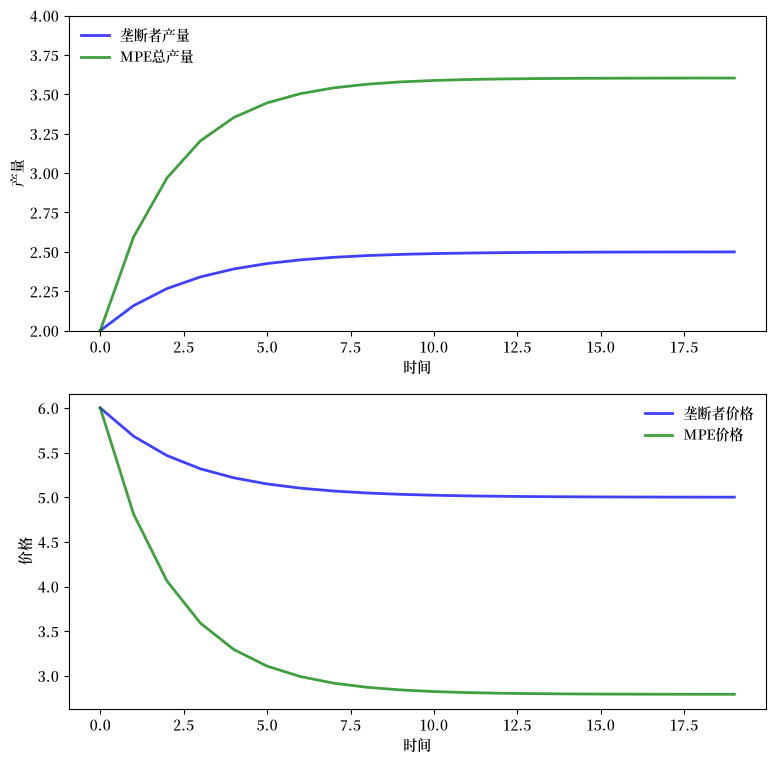

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(9, 9))

ax = axes[0]
ax.plot(qm, 'b-', lw=2, alpha=0.75, label='垄断者产量')
ax.plot(q, 'g-', lw=2, alpha=0.75, label='MPE总产量')
ax.set(ylabel="产量", xlabel="时间", ylim=(2, 4))
ax.legend(loc='upper left', frameon=0)

ax = axes[1]
ax.plot(pm, 'b-', lw=2, alpha=0.75, label='垄断者价格')
ax.plot(p, 'g-', lw=2, alpha=0.75, label='MPE价格')
ax.set(ylabel="价格", xlabel="时间")
ax.legend(loc='upper right', frameon=0)
plt.show()

```{solution-end}
```

```{exercise-start}
:label: mp_ex2
```

在本练习中，我们考虑一个稍微复杂一点的双寡头问题。

这是由Judd {cite}`Judd1990`提出的一个无限期线性二次博弈。

两家公司通过需求曲线的相互关联来设定两种商品的价格和数量。

相关变量定义如下：

* $I_{it}$ = t期初第i家公司的库存
* $q_{it}$ = t期间第i家公司的生产量
* $p_{it}$ = t期间第i家公司收取的价格
* $S_{it}$ = t期间第i家公司的销售量
* $E_{it}$ = t期间第i家公司的生产成本
* $C_{it}$ = t期间第i家公司的库存持有成本

公司的成本函数为：

* $C_{it} = c_{i1} + c_{i2} I_{it} + 0.5 c_{i3} I_{it}^2$
* $E_{it} = e_{i1} + e_{i2}q_{it} + 0.5 e_{i3} q_{it}^2$ 其中 $e_{ij}, c_{ij}$ 为正标量

库存遵循以下运动规律：

$$
I_{i,t+1} = (1 - \delta)  I_{it} + q_{it} - S_{it}
$$

需求由线性方程决定

$$
S_t = D p_{it} + b
$$

其中

* $S_t = \begin{bmatrix} S_{1t} & S_{2t} \end{bmatrix}'$
* $D$ 是一个 $2\times 2$ 负定矩阵
* $b$ 是常数向量

公司 $i$ 最大化未贴现总和

$$
\lim_{T \to \infty}\ {1 \over T}\   \sum^T_{t=0}\   \left( p_{it} S_{it} - E_{it} - C_{it} \right)
$$

我们可以通过以下方式将其转换为线性二次规划问题

$$
u_{it} =
\begin{bmatrix}
    p_{it} \\
    q_{it}
\end{bmatrix}
\quad \text{and} \quad
x_t =
\begin{bmatrix}
    I_{1t} \\
    I_{2t} \\
    1
\end{bmatrix}
$$

价格和数量的决策规则采用形式 $u_{it} = -F_i  x_t$。

通过适当填充矩阵可以计算出Judd模型的马尔可夫完美均衡。

练习是计算这些矩阵并计算以下图形。

第一个图显示了在给定参数下每个公司的库存动态变化。

In [11]:
δ = 0.02
D = np.array([[-1, 0.5], [0.5, -1]])
b = np.array([25, 25])
c1 = c2 = np.array([1, -2, 1])
e1 = e2 = np.array([10, 10, 3])

```{image} /_static/lecture_specific/markov_perf/judd_fig2.png
:align: center
```

库存量趋向于一个共同的稳态。

如果我们将折旧率提高到 $\delta = 0.05$，那么预计稳态库存量会下降。

正如下图所示，确实如此

```{image} /_static/lecture_specific/markov_perf/judd_fig1.png
:align: center
```

在这个练习中，重现 $\delta = 0.02$ 时的图形。

```{exercise-end}
```

```{solution-start} mp_ex2
:class: dropdown
```

我们处理 $\delta = 0.02$ 的情况

In [12]:
δ = 0.02
D = np.array([[-1, 0.5], [0.5, -1]])
b = np.array([25, 25])
c1 = c2 = np.array([1, -2, 1])
e1 = e2 = np.array([10, 10, 3])

δ_1 = 1 - δ

回想控制和状态为

$$
u_{it} =
\begin{bmatrix}
    p_{it} \\
    q_{it}
\end{bmatrix}
\quad \text{and} \quad
x_t =
\begin{bmatrix}
    I_{1t} \\
    I_{2t} \\
    1
\end{bmatrix}
$$

我们按如下方式设置矩阵：

In [13]:
# ==  创建计算纳什反馈均衡所需的矩阵 == #

A = np.array([[δ_1,      0,    -δ_1 * b[0]],
              [  0,    δ_1,    -δ_1 * b[1]],
              [  0,      0,             1]])

B1 = δ_1 * np.array([[1, -D[0, 0]],
                     [0, -D[1, 0]],
                     [0,       0]])
B2 = δ_1 * np.array([[0, -D[0, 1]],
                     [1, -D[1, 1]],
                     [0,       0]])

R1 = -np.array([[0.5 * c1[2],     0,    0.5 * c1[1]],
                [          0,     0,              0],
                [0.5 * c1[1],     0,         c1[0]]])
R2 = -np.array([[0,               0,              0],
                [0,     0.5 * c2[2],    0.5 * c2[1]],
                [0,     0.5 * c2[1],         c2[0]]])

Q1 = np.array([[-0.5 * e1[2], 0], [0, D[0, 0]]])
Q2 = np.array([[-0.5 * e2[2], 0], [0, D[1, 1]]])

S1 = np.zeros((2, 2))
S2 = np.copy(S1)

W1 = np.array([[           0,             0],
               [           0,             0],
               [-0.5 * e1[1],    b[0] / 2.]])
W2 = np.array([[           0,             0],
               [           0,             0],
               [-0.5 * e2[1],    b[1] / 2.]])

M1 = np.array([[0, 0], [0, D[0, 1] / 2.]])
M2 = np.copy(M1)

现在我们可以使用`qe.nnash`来计算均衡

In [14]:
F1, F2, P1, P2 = qe.nnash(A, B1, B2, R1,
                          R2, Q1, Q2, S1,
                          S2, W1, W2, M1, M2)

print("\n公司1的反馈规则：\n")
print(F1)

print("\n公司2的反馈规则：\n")
print(F2)


公司1的反馈规则：

[[ 2.43666582e-01  2.72360627e-02 -6.82788293e+00]
 [ 3.92370734e-01  1.39696451e-01 -3.77341073e+01]]

公司2的反馈规则：

[[ 2.72360627e-02  2.43666582e-01 -6.82788293e+00]
 [ 1.39696451e-01  3.92370734e-01 -3.77341073e+01]]


现在让我们来看看库存的动态变化，并重现对应于$\delta = 0.02$的图表

findfont: Failed to find font weight normal, now using 600.


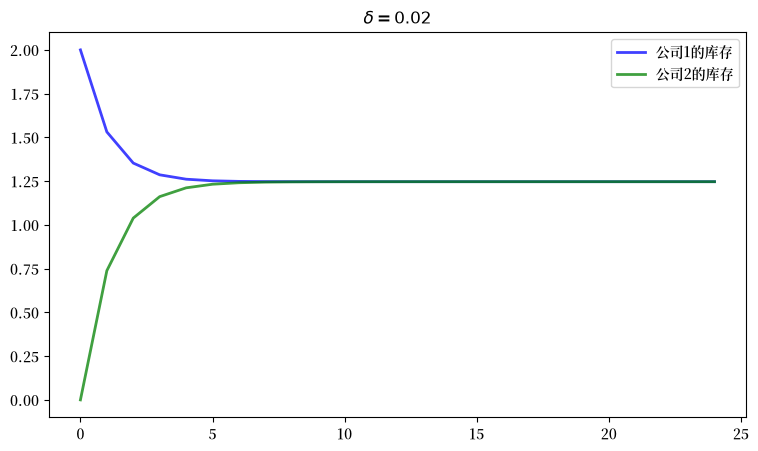

In [15]:
AF = A - B1 @ F1 - B2 @ F2
n = 25
x = np.empty((3, n))
x[:, 0] = 2, 0, 1
for t in range(n-1):
    x[:, t+1] = AF @ x[:, t]
I1 = x[0, :]
I2 = x[1, :]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(I1, 'b-', lw=2, alpha=0.75, label='公司1的库存')
ax.plot(I2, 'g-', lw=2, alpha=0.75, label='公司2的库存')
ax.set_title(rf'$\delta = {δ}$')
ax.legend()
plt.show()

```{solution-end}
```